In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import warnings
warnings.filterwarnings('ignore')

## 1. Load Data

In [2]:
# 1. Load Data
df = pd.read_excel('PJMW_MW_Hourly.xlsx')
df

,Datetime,PJMW_MW
0,2002-12-31 01:00:00,5077
1,2002-12-31 02:00:00,4939
2,2002-12-31 03:00:00,4885
3,2002-12-31 04:00:00,4857
4,2002-12-31 05:00:00,4930
...,...,...
143201,2018-01-01 20:00:00,8401
143202,2018-01-01 21:00:00,8373
143203,2018-01-01 22:00:00,8238
143204,2018-01-01 23:00:00,7958


In [3]:
#Check Row & Columns
df.shape

(143206, 2)

In [4]:
#Check Columns name
df.columns

Index(['Datetime', 'PJMW_MW'], dtype='object')

## Data Cleaning

In [5]:
#Check Null Values(missing values)
df.isnull().sum()

Datetime    0
PJMW_MW     0
dtype: int64

In [6]:
#Check Duplicate values in dataset
print(df.duplicated().sum())

0


In [7]:
#check Non-Null values with there Datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143206 entries, 0 to 143205
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   Datetime  143206 non-null  datetime64[ns]
 1   PJMW_MW   143206 non-null  int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.2 MB


## ADF Test

In [8]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['PJMW_MW'])

print("ADF Statistic :", result[0])
print("p-value :", result[1])

if result[1] <= 0.05:
    print("Data is Stationary")
else:
    print("Data is Non-Stationary")

ADF Statistic : -19.530978788978082
p-value : 0.0
Data is Stationary


## 2. Data Preprocessing

In [9]:
# index type
print(type(df.index))

<class 'pandas.core.indexes.range.RangeIndex'>


The Date column was already stored as a datetime datatype, so I did not need to convert it. However, the dataset was using a RangeIndex. Since time series operations work more efficiently with a DateTimeIndex, I set the Date column as the index before performing feature engineering, visualization, and forecasting.

In [10]:
#sort_values puts the data in chronological order (oldest to newest)
#which is mandatory for time-series.
df = df.sort_values('Datetime') 
df.head()


,Datetime,PJMW_MW
6574,2002-04-01 01:00:00,4374
6575,2002-04-01 02:00:00,4306
6576,2002-04-01 03:00:00,4322
6577,2002-04-01 04:00:00,4359
6578,2002-04-01 05:00:00,4436


In [11]:
df.tail()

,Datetime,PJMW_MW
138090,2018-08-02 20:00:00,6545
138091,2018-08-02 21:00:00,6496
138092,2018-08-02 22:00:00,6325
138093,2018-08-02 23:00:00,5892
138094,2018-08-03 00:00:00,5489


In [12]:
# Set Date column as index
df.set_index('Datetime', inplace=True)

In [13]:
# Verify index type
print(type(df.index))

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


## Feature engineering

Electricity demand changes according to:

Hour
Weekday
Month
Season
Day

These features help the model learn patterns.

In [14]:
#Feature Extraction for EDA
df['Hour'] = df.index.hour
df['DayOfWeek'] = df.index.dayofweek
df['Month'] = df.index.month
df['Year'] = df.index.year
df['DayOfYear'] = df.index.dayofyear
df['weekofyear'] = df.index.isocalendar().week.astype(int)

In [15]:
!pip install holidays

Power consumption patterns on holidays differ significantly from regular working days. I created an Is_Holiday feature so that the model could learn holiday-related demand variations and improve forecasting accuracy

In [16]:
# Add US Holidays
import holidays

us_holidays = holidays.US()

df['Is_Holiday'] = df.index.date

#Convert dates into 1 (holiday) or 0 (non holiday)
df['Is_Holiday'] = df['Is_Holiday'].map(
    lambda x: 1 if x in us_holidays else 0
)

In [17]:
df.columns

Index(['PJMW_MW', 'Hour', 'DayOfWeek', 'Month', 'Year', 'DayOfYear',
       'weekofyear', 'Is_Holiday'],
      dtype='object')

In [18]:
df

,PJMW_MW,Hour,DayOfWeek,Month,Year,DayOfYear,weekofyear,Is_Holiday
Datetime,,,,,,,,
2002-04-01 01:00:00,4374,1,0,4,2002,91,14,0
2002-04-01 02:00:00,4306,2,0,4,2002,91,14,0
2002-04-01 03:00:00,4322,3,0,4,2002,91,14,0
2002-04-01 04:00:00,4359,4,0,4,2002,91,14,0
2002-04-01 05:00:00,4436,5,0,4,2002,91,14,0
...,...,...,...,...,...,...,...,...
2018-08-02 20:00:00,6545,20,3,8,2018,214,31,0
2018-08-02 21:00:00,6496,21,3,8,2018,214,31,0
2018-08-02 22:00:00,6325,22,3,8,2018,214,31,0


In [19]:
### Save Cleaned dataset
df.to_csv("Cleaned_Dataset.csv", index=False)

In [20]:
df.describe()

,PJMW_MW,Hour,DayOfWeek,Month,Year,DayOfYear,weekofyear,Is_Holiday
count,143206.000000,143206.000000,143206.000000,143206.000000,143206.000000,143206.000000,143206.000000,143206.000000
mean,5602.375089,11.501620,2.998492,6.502835,2009.918691,182.494365,26.507381,0.030166
std,979.142872,6.921789,1.999696,3.419536,4.730344,104.554713,14.939033,0.171045
min,487.000000,0.000000,0.000000,1.000000,2002.000000,1.000000,1.000000,0.000000
25%,4907.000000,6.000000,1.000000,4.000000,2006.000000,94.000000,14.000000,0.000000
50%,5530.000000,12.000000,3.000000,6.000000,2010.000000,181.000000,26.000000,0.000000
75%,6252.000000,18.000000,5.000000,9.000000,2014.000000,272.000000,39.000000,0.000000
max,9594.000000,23.000000,6.000000,12.000000,2018.000000,366.000000,53.000000,1.000000


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 143206 entries, 2002-04-01 01:00:00 to 2018-08-03 00:00:00
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   PJMW_MW     143206 non-null  int64
 1   Hour        143206 non-null  int32
 2   DayOfWeek   143206 non-null  int32
 3   Month       143206 non-null  int32
 4   Year        143206 non-null  int32
 5   DayOfYear   143206 non-null  int32
 6   weekofyear  143206 non-null  int64
 7   Is_Holiday  143206 non-null  int64
dtypes: int32(5), int64(3)
memory usage: 7.1 MB


## 3. EDA(EXPLORATORY DATA ANALYSIS)

### 1.Histogram Plot

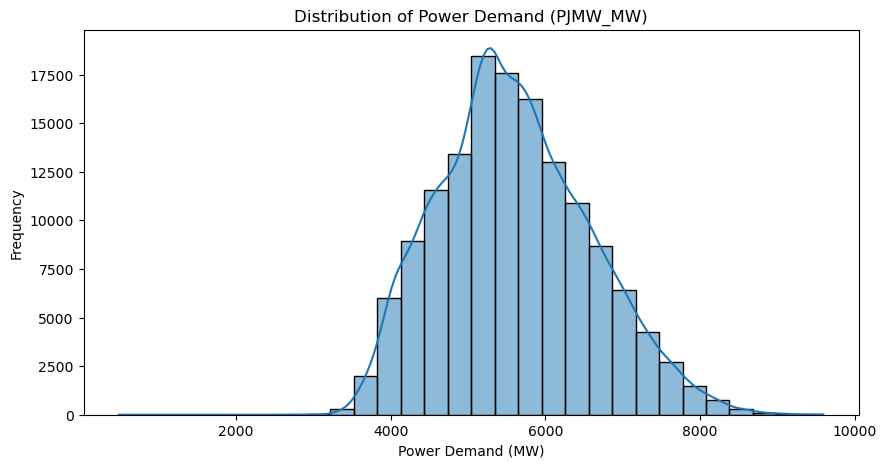

In [22]:
plt.figure(figsize=(10,5))
sns.histplot(df['PJMW_MW'], kde=True, bins=30)
plt.title('Distribution of Power Demand (PJMW_MW)')
plt.xlabel('Power Demand (MW)')
plt.ylabel('Frequency')
plt.show()

The distribution is approximately bell-shaped (near normal distribution).
There is a slight right skew

### 2. BOX PLOT  (Monthly Boxplot)

In [23]:
print(type(df.index))
df.columns

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


Index(['PJMW_MW', 'Hour', 'DayOfWeek', 'Month', 'Year', 'DayOfYear',
       'weekofyear', 'Is_Holiday'],
      dtype='object')

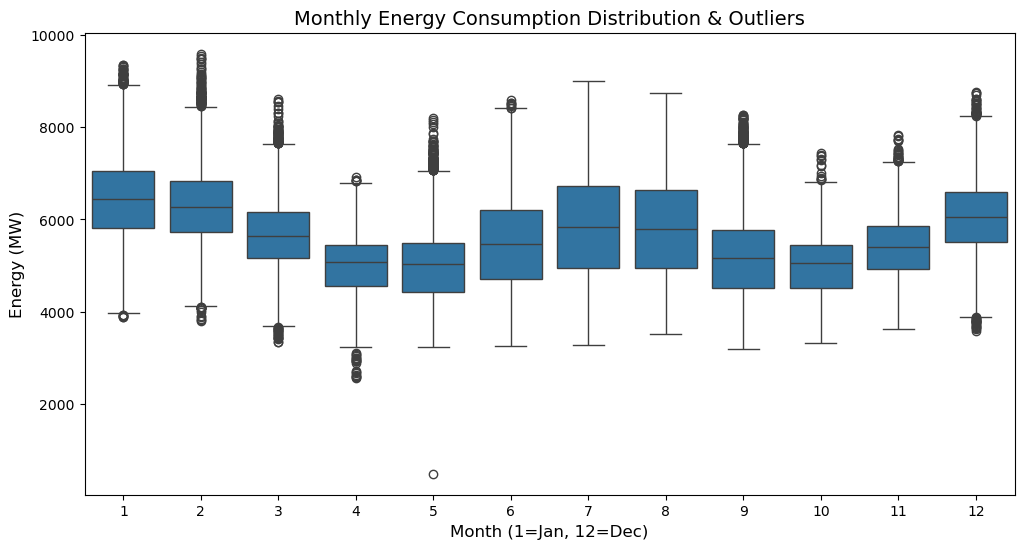

In [24]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Month', y='PJMW_MW')
plt.title('Monthly Energy Consumption Distribution & Outliers', fontsize=14)
plt.xlabel('Month (1=Jan, 12=Dec)', fontsize=12)
plt.ylabel('Energy (MW)', fontsize=12)
plt.xticks(range(12))
plt.show()

In energy consumption, an outlier is usually a real, critical event: a massive heatwave forcing everyone to turn on AC simultaneously, or a severe winter freeze causing record heating demand. If you remove them, your model will never learn how to predict extreme days. That's why we can't remove or capping them.

According to the problem statement we Need to find Hourly trend , Holiday Trend, Long-term-Trend and Summer VS Winter seasonality Daily Trend

### 1. Hourly Trend

In [25]:
# Set plot style
sns.set_style('whitegrid')

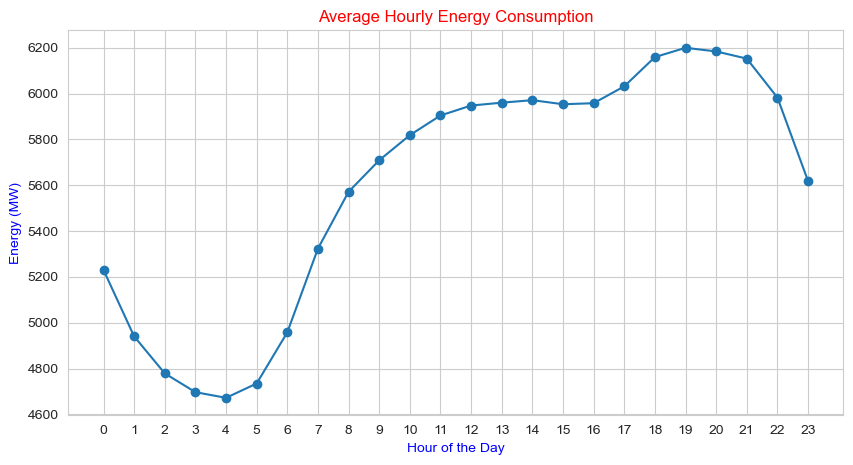

In [26]:
hourly_avg = df.groupby('Hour')['PJMW_MW'].mean()
plt.figure(figsize=(10, 5))
hourly_avg.plot(kind='line', marker='o')
plt.title('Average Hourly Energy Consumption',color='r')
plt.xlabel('Hour of the Day',color='b')
plt.ylabel('Energy (MW)',color='b')
plt.xticks(range(24))
plt.show()

Observations:
•	Lowest demand: 3 AM–5 AM (Electricity demand is lowest in the early morning hours)
•	Highest demand: 6 PM–9 PM (highest during the evening , with the peak occurring around 7 PM.)

I observe that demand increases during active hours and decreases during night hours.


## 2. Holiday vs Non-Holiday Trends

<Figure size 1000x500 with 0 Axes>

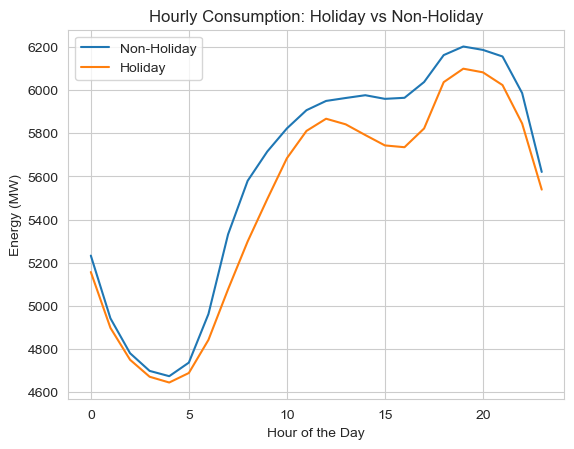

In [27]:
#unstack() converts one level of a MultiIndex from rows into columns.
#0 = Non-Holiday, Column 1 = Holiday
#Hour = 0 → 12 AM, Hour = 1 → 1 AM
plt.figure(figsize=(10, 5))
holiday_avg = df.groupby(['Hour', 'Is_Holiday'])['PJMW_MW'].mean().unstack() 
holiday_avg.plot()
plt.title('Hourly Consumption: Holiday vs Non-Holiday')
plt.xlabel('Hour of the Day')
plt.ylabel('Energy (MW)')
plt.legend(['Non-Holiday', 'Holiday'])
plt.show()

Observation:
1.	Lowest power consumption occurs between 3 AM – 5 AM.
2.	Demand starts increasing rapidly after 6 AM.

Holiday demand is lower because commercial and industrial activities are reduced. The graph indicates that working days require more electricity than holidays.

## 3. Long Term Trends

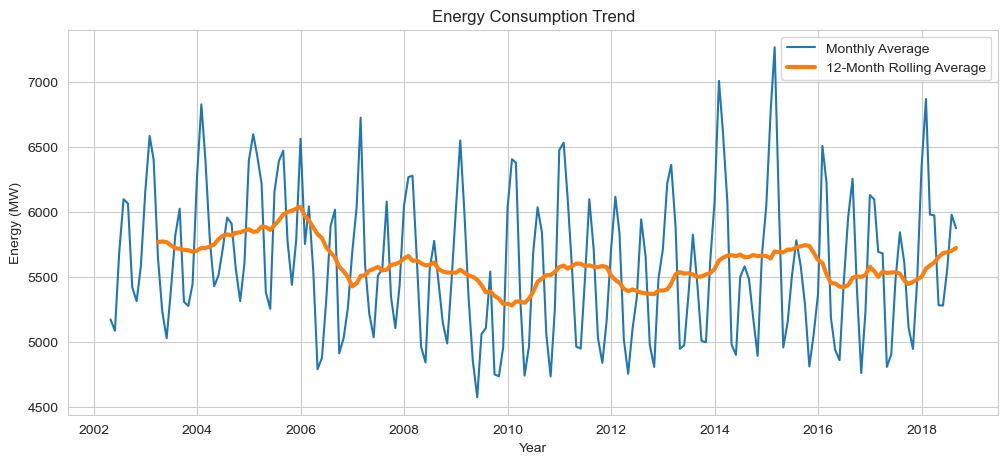

In [28]:
# Monthly Average Energy Consumption
monthly_avg = df['PJMW_MW'].resample('ME').mean()

# 12-Month Rolling Average
rolling_avg = monthly_avg.rolling(12).mean()

# Plot
plt.figure(figsize=(12,5))

plt.plot(monthly_avg, label='Monthly Average')

plt.plot(rolling_avg,
         label='12-Month Rolling Average',
         linewidth=3)

plt.title('Energy Consumption Trend')
plt.xlabel('Year')
plt.ylabel('Energy (MW)')
plt.legend()

plt.show()

Conclusion-

The dataset exhibits strong seasonality, while the long-term electricity demand remains relatively stable with only mild fluctuations over the years.

### 4. Summer vs Winter Trends

<Figure size 1000x600 with 0 Axes>

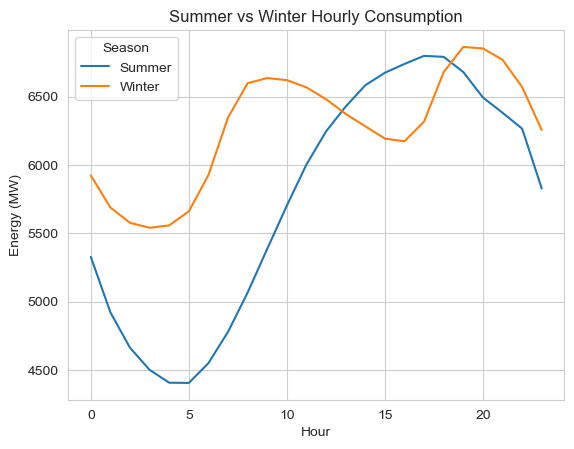

In [29]:
# Create Season Column
df['Season'] = 'Other'

df.loc[df['Month'].isin([6,7,8]), 'Season'] = 'Summer'
df.loc[df['Month'].isin([12,1,2]), 'Season'] = 'Winter'

# Keep only Summer and Winter data( Keep rows that are NOT Other)
season_data = df[df['Season'] != 'Other']

# Calculate average hourly consumption
seasonal_hourly = season_data.groupby(
    ['Hour', 'Season']
)['PJMW_MW'].mean().unstack()

# Plot
plt.figure(figsize=(10,6))

seasonal_hourly.plot()

plt.title('Summer vs Winter Hourly Consumption')
plt.xlabel('Hour')
plt.ylabel('Energy (MW)')

plt.show()

Conclusion-
Summer demand is higher during afternoon hours, while Winter demand is higher during morning and evening hours, showing clear seasonal effects on electricity consumption.

### Seasonal Decomposition

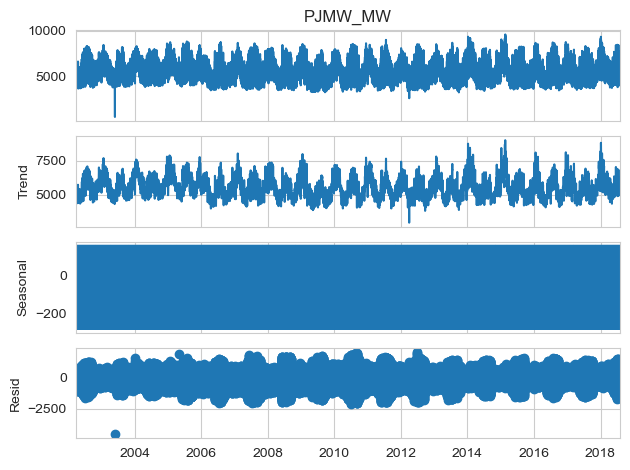

In [30]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(
    df['PJMW_MW'],
    model='additive',
    period=24
)

result.plot()
plt.show()

Seasonal Decomposition Observations-
The energy consumption series shows a clear recurring pattern over time.
The trend component indicates long-term fluctuations in electricity demand.
The seasonal component confirms the presence of regular daily consumption cycles.
The residual component contains random variations and unexpected demand changes not explained by trend or seasonality.
Seasonal patterns remain relatively consistent throughout the observation period.
The decomposition suggests that electricity demand is influenced by both trend and seasonal effects.
The presence of seasonality justifies the use of lag and rolling features in the forecasting model.

Seasonal decomposition was used to separate the electricity demand data into Trend, Seasonal, and Residual components. The results revealed clear daily seasonal patterns and long-term demand variations, confirming that time-based and lag features are important for accurate forecasting.

### Autocorrelation Plot

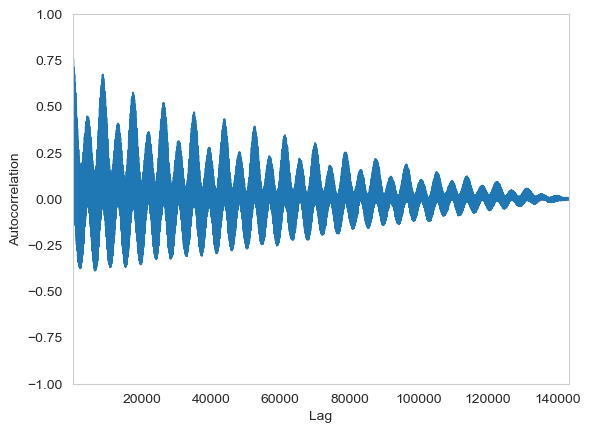

In [31]:
from pandas.plotting import autocorrelation_plot

autocorrelation_plot(df['PJMW_MW'])
plt.show()

plot shows a strong relationship between current and past electricity demand values.The existence of significant autocorrelation justifies the use of lag features (lag_24, lag_168) in the forecasting model.
The autocorrelation analysis revealed that electricity demand is highly correlated with previous observations. Therefore, we created lag_24 to capture the demand from the same hour of the previous day and lag_168 to capture the demand from the same hour of the previous week. These features help the model learn recurring consumption patterns and improve forecast accuracy.

## 2: Model Building

### 1. Feature Engineering for Machine Learning

In [32]:
 # Lag features (Consumption at the same hour yesterday and last week)
df['lag_24'] = df['PJMW_MW'].shift(24)
df['lag_168'] = df['PJMW_MW'].shift(168)
    
# Rolling features (24-hour rolling average)
df['rolling_mean_24'] = df['PJMW_MW'].rolling(24).mean()
df['rolling_std_24'] = df['PJMW_MW'].rolling(window=24).std()

In [33]:
df

,PJMW_MW,Hour,DayOfWeek,Month,Year,DayOfYear,weekofyear,Is_Holiday,Season,lag_24,lag_168,rolling_mean_24,rolling_std_24
Datetime,,,,,,,,,,,,,
2002-04-01 01:00:00,4374,1,0,4,2002,91,14,0,Other,NaN,NaN,NaN,NaN
2002-04-01 02:00:00,4306,2,0,4,2002,91,14,0,Other,NaN,NaN,NaN,NaN
2002-04-01 03:00:00,4322,3,0,4,2002,91,14,0,Other,NaN,NaN,NaN,NaN
2002-04-01 04:00:00,4359,4,0,4,2002,91,14,0,Other,NaN,NaN,NaN,NaN
2002-04-01 05:00:00,4436,5,0,4,2002,91,14,0,Other,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-08-02 20:00:00,6545,20,3,8,2018,214,31,0,Summer,6816.0,7354.0,5809.250000,762.020384
2018-08-02 21:00:00,6496,21,3,8,2018,214,31,0,Summer,6571.0,7063.0,5806.125000,758.908101
2018-08-02 22:00:00,6325,22,3,8,2018,214,31,0,Summer,6362.0,6895.0,5804.583333,757.766507


Season column created during the Visualization and it is contain categorical data. We have a month column for checking season. If I keep this column model read the duplicate information, which can confuse the model and make it less accurate. To Avoid redundancy and Multicolinearity, that's why I drop this columns 

In [34]:
#Now we drop it for ML
df = df.drop(columns=['Season'])

#Remove missing values which created by lag features:
data = df.dropna()
df

,PJMW_MW,Hour,DayOfWeek,Month,Year,DayOfYear,weekofyear,Is_Holiday,lag_24,lag_168,rolling_mean_24,rolling_std_24
Datetime,,,,,,,,,,,,
2002-04-01 01:00:00,4374,1,0,4,2002,91,14,0,NaN,NaN,NaN,NaN
2002-04-01 02:00:00,4306,2,0,4,2002,91,14,0,NaN,NaN,NaN,NaN
2002-04-01 03:00:00,4322,3,0,4,2002,91,14,0,NaN,NaN,NaN,NaN
2002-04-01 04:00:00,4359,4,0,4,2002,91,14,0,NaN,NaN,NaN,NaN
2002-04-01 05:00:00,4436,5,0,4,2002,91,14,0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2018-08-02 20:00:00,6545,20,3,8,2018,214,31,0,6816.0,7354.0,5809.250000,762.020384
2018-08-02 21:00:00,6496,21,3,8,2018,214,31,0,6571.0,7063.0,5806.125000,758.908101
2018-08-02 22:00:00,6325,22,3,8,2018,214,31,0,6362.0,6895.0,5804.583333,757.766507


In [35]:
df.columns

Index(['PJMW_MW', 'Hour', 'DayOfWeek', 'Month', 'Year', 'DayOfYear',
       'weekofyear', 'Is_Holiday', 'lag_24', 'lag_168', 'rolling_mean_24',
       'rolling_std_24'],
      dtype='object')

### 2. Train/Test Split 

In [36]:
#Last Year = Test Set
#Previous Year= Training Set
# X=Feature variables, y= Target variable

In [37]:
#X- Features (input data)
#y-Target (output to predict)
X = data[['Hour','DayOfWeek','Month','Year',
          'DayOfYear','weekofyear','Is_Holiday',
          'lag_24','lag_168','rolling_mean_24','rolling_std_24']]

y = data['PJMW_MW']

In [38]:
#Now we are spilting data into X_train, y_train, X_test & y_test

train = data[data.index < '2018-01-01']
test = data[data.index >= '2018-01-01']

X_train = train[X.columns]
y_train = train['PJMW_MW']

X_test = test[X.columns]
y_test = test['PJMW_MW']

print(f"Training samples : {len(X_train):,}")
print(f"Testing samples  : {len(X_test):,}")

Training samples : 137,902
Testing samples  : 5,136


In [39]:
##Save train and Test Dataset
X_train.to_csv("Train_Dataset.csv", index=False)
X_test.to_csv("Test_Dataset.csv", index=False)

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [41]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

# 3. Train Models

In [42]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

import xgboost as xgb
import lightgbm as lgb


## EVALUATION Matrics

In [43]:
def evaluate(name, y_true, y_pred, results_dict):
    rmse = root_mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)

    results_dict[name] = {
        'RMSE': rmse,
        'MAE': mae,
        'MAPE (%)': mape,
        'R2': r2
    }

    print(f"\n{name}")
    print(f"  RMSE     : {rmse:.2f} MW")
    print(f"  MAE      : {mae:.2f} MW")
    print(f"  MAPE     : {mape:.2f}%")
    print(f"  R2 Score : {r2:.3f}")

results = {}

### 1. XGBoost Model

In [44]:
xgb_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    early_stopping_rounds=50,
    eval_metric='rmse',
    random_state=42
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

xgb_pred = xgb_model.predict(X_test)
test['XGB_Prediction'] = xgb_pred
evaluate('XGBoost', y_test, xgb_pred, results)


XGBoost
  RMSE     : 226.25 MW
  MAE      : 168.93 MW
  MAPE     : 2.82%
  R2 Score : 0.950


### 2. RANDOM FOREST

In [45]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
test['RF_Prediction'] = rf_pred
evaluate('Random Forest', y_test, rf_pred, results)


Random Forest
  RMSE     : 298.14 MW
  MAE      : 231.33 MW
  MAPE     : 3.94%
  R2 Score : 0.914


### 3. LightGBM

In [46]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    verbose=-1
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)

lgb_pred = lgb_model.predict(X_test)
test['LGB_Prediction'] = lgb_pred
evaluate('LightGBM', y_test, lgb_pred, results)


LightGBM
  RMSE     : 226.85 MW
  MAE      : 172.92 MW
  MAPE     : 2.89%
  R2 Score : 0.950


### 4 SARIMA Model

In [47]:
# Count duplicate datetime values
print(train.index.duplicated().sum())

4


In [48]:
train = train[~train.index.duplicated(keep='first')]
test = test[~test.index.duplicated(keep='first')]

train = train.asfreq('h')
test = test.asfreq('h')

In [49]:
print(train.index.is_unique)


True


In [50]:
print(df.shape)
print(df.index.min())
print(df.index.max())

(143206, 12)
2002-04-01 01:00:00
2018-08-03 00:00:00


In [51]:
 #80% train, 20% test split

split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

print("Train rows:", len(train))
print("Test rows:", len(test))

Train rows: 114564
Test rows: 28642


In [52]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
# Remove missing values if any
train = train.dropna()

train_small = train.tail(1000)

sarima_model = SARIMAX(
    train_small['PJMW_MW'],
    order=(1,1,1),
    seasonal_order=(1,1,1,24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())

C:\Users\Aarti\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
C:\Users\Aarti\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                            PJMW_MW   No. Observations:                 1000
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 24)   Log Likelihood               -5369.313
Date:                            Sun, 28 Jun 2026   AIC                          10748.627
Time:                                    13:08:59   BIC                          10772.904
Sample:                                03-16-2015   HQIC                         10757.877
                                     - 04-27-2015                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4291      0.044      9.766      0.000       0.343       0.515
ma.L1          0.1069      0.050   

In [54]:
train_small = train.tail(1000)
sarima_pred = sarima_fit.forecast(steps=len(y_test))
test['Sarima_Prediction'] = sarima_pred 
evaluate('SARIMA', y_test, sarima_pred, results)



SARIMA
  RMSE     : 4318.09 MW
  MAE      : 3705.50 MW
  MAPE     : nan%
  R2 Score : -17.064


In [55]:
print((y_test == 0).sum())

0


### BASELINE MODEL (NAIVE PERSISTENCE)

In [56]:
baseline_pred = X_test['lag_168']  # last week, same hour
evaluate('Baseline Model', y_test, baseline_pred, results)


Baseline Model
  RMSE     : 876.31 MW
  MAE      : 657.64 MW
  MAPE     : 11.16%
  R2 Score : 0.256


In [57]:
print('xgb_pred shape:', len(xgb_pred))
print('rf_pred shape:', len(rf_pred))
print('lgb_pred shape:', len(lgb_pred))
print('sarima_pred shape:',len(sarima_pred))

xgb_pred shape: 5136
rf_pred shape: 5136
lgb_pred shape: 5136
sarima_pred shape: 5136


In [58]:
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print("test:", test.shape)

X_test: (5136, 11)
y_test: (5136,)
test: (28642, 13)


In [59]:
print(test.columns.tolist())

['PJMW_MW', 'Hour', 'DayOfWeek', 'Month', 'Year', 'DayOfYear', 'weekofyear', 'Is_Holiday', 'lag_24', 'lag_168', 'rolling_mean_24', 'rolling_std_24', 'Sarima_Prediction']


In [60]:
pred_res = pd.DataFrame(index=y_test.index)

pred_res['Actual'] = y_test.values
pred_res['XGB_Prediction'] = xgb_pred
pred_res['RF_Prediction'] = rf_pred
pred_res['LGB_Prediction'] = lgb_pred
pred_res['Sarima_Prediction'] = sarima_pred.values
pred_res[['Actual',
      'XGB_Prediction',
      'RF_Prediction',
      'LGB_Prediction',
      'Sarima_Prediction']].to_csv(
          'test_predictions.csv'
)

In [61]:
print(pred_res.columns.tolist())

['Actual', 'XGB_Prediction', 'RF_Prediction', 'LGB_Prediction', 'Sarima_Prediction']


### Model Comparison

In [69]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('RMSE')

print("=" * 50)
print("MODEL COMPARISON (sorted by RMSE, lower = better)")
print("=" * 50)
print(results_df.round(3))
#Save table
results_df.to_csv("Actual_vs_Predicted_All_Models.csv", index=False)

best_model_name = results_df.index[0]
print(f"\nBest model: {best_model_name}")

MODEL COMPARISON (sorted by RMSE, lower = better)
                    RMSE       MAE  MAPE (%)      R2
XGBoost          226.254   168.932     2.815   0.950
LightGBM         226.854   172.923     2.894   0.950
Random Forest    298.143   231.334     3.935   0.914
Baseline Model   876.312   657.639    11.165   0.256
SARIMA          4318.087  3705.504       NaN -17.064

Best model: XGBoost


### FEATURE IMPORTANCE PLOTS

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

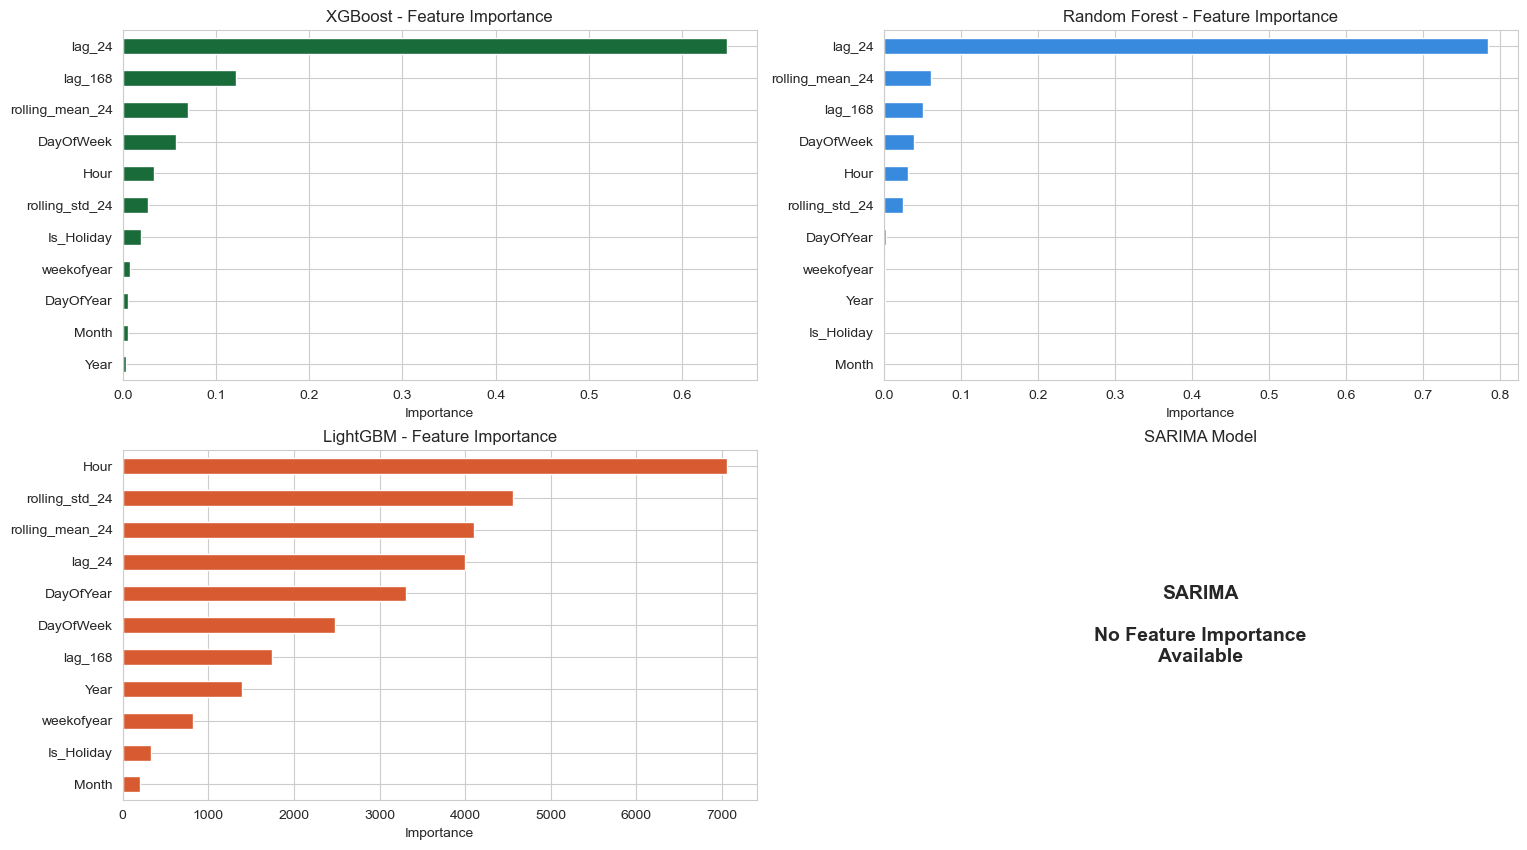

In [70]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

xgb_importance = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values()
xgb_importance.plot(kind='barh', ax=axes[0,0], color='#1a6b3a')
axes[0,0].set_title('XGBoost - Feature Importance')
axes[0,0].set_xlabel('Importance')

rf_importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values()
rf_importance.plot(kind='barh', ax=axes[0,1], color='#378ADD')
axes[0,1].set_title('Random Forest - Feature Importance')
axes[0,1].set_xlabel('Importance')

lgb_importance = pd.Series(lgb_model.feature_importances_, index=X.columns).sort_values()
lgb_importance.plot(kind='barh', ax=axes[1,0], color='#D85A30')
axes[1,0].set_title('LightGBM - Feature Importance')
axes[1,0].set_xlabel('Importance')

axes[1,1].text(
    0.5,
    0.5,
    "SARIMA\n\nNo Feature Importance\nAvailable",
    ha='center',
    va='center',
    fontsize=14,
    fontweight='bold'
)

axes[1,1].set_title('SARIMA Model')
axes[1,1].axis('off')

## 5. Actual vs predicted (all models, first week)

In [71]:
print(test.columns.tolist())

['PJMW_MW', 'Hour', 'DayOfWeek', 'Month', 'Year', 'DayOfYear', 'weekofyear', 'Is_Holiday', 'lag_24', 'lag_168', 'rolling_mean_24', 'rolling_std_24', 'Sarima_Prediction']


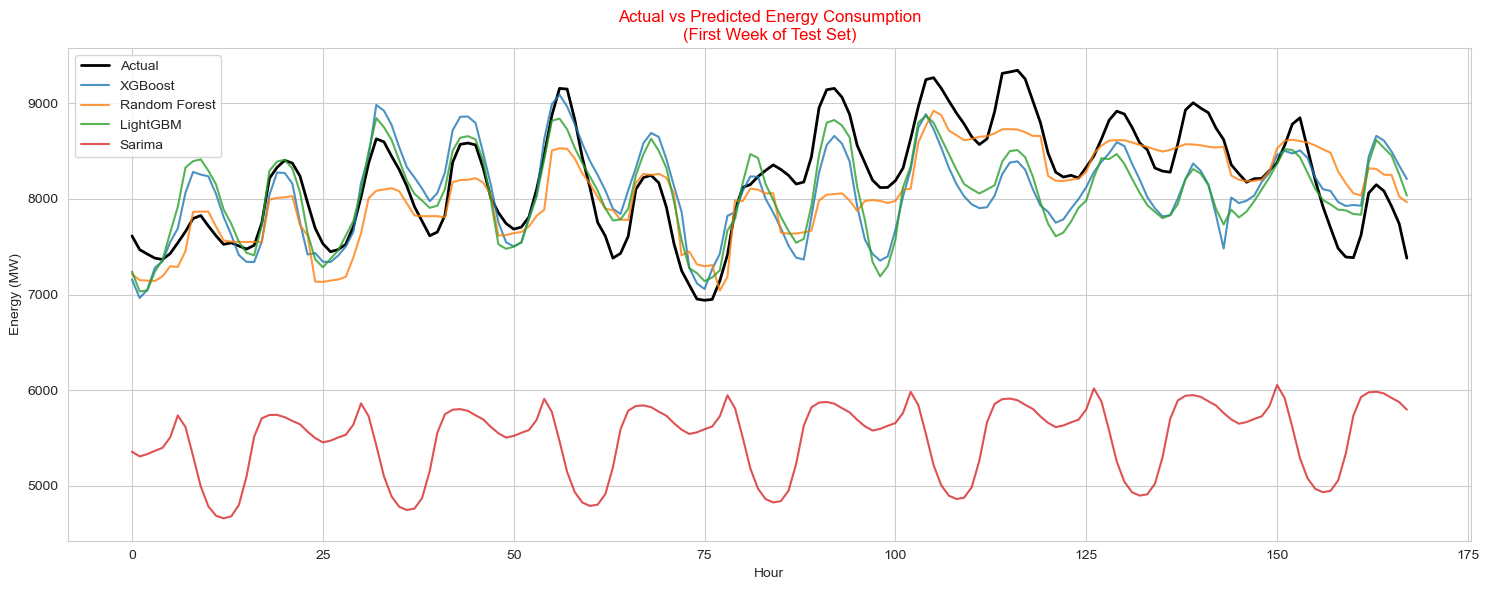

In [72]:
plt.figure(figsize=(15, 6))

plt.plot(pred_res['Actual'].iloc[:168].values, label='Actual', linewidth=2, color='black')
plt.plot(pred_res['XGB_Prediction'].iloc[:168].values, label='XGBoost', alpha=0.8)
plt.plot(pred_res['RF_Prediction'].iloc[:168].values, label='Random Forest', alpha=0.8)
plt.plot(pred_res['LGB_Prediction'].iloc[:168].values, label='LightGBM', alpha=0.8)
plt.plot(pred_res['Sarima_Prediction'].iloc[:168].values, label='Sarima', alpha=0.8)

plt.title('Actual vs Predicted Energy Consumption\n(First Week of Test Set)', color='red')
plt.xlabel('Hour')
plt.ylabel('Energy (MW)')
plt.legend()
plt.tight_layout()
plt.show()

### Actual vs predicted (best model, full test set)

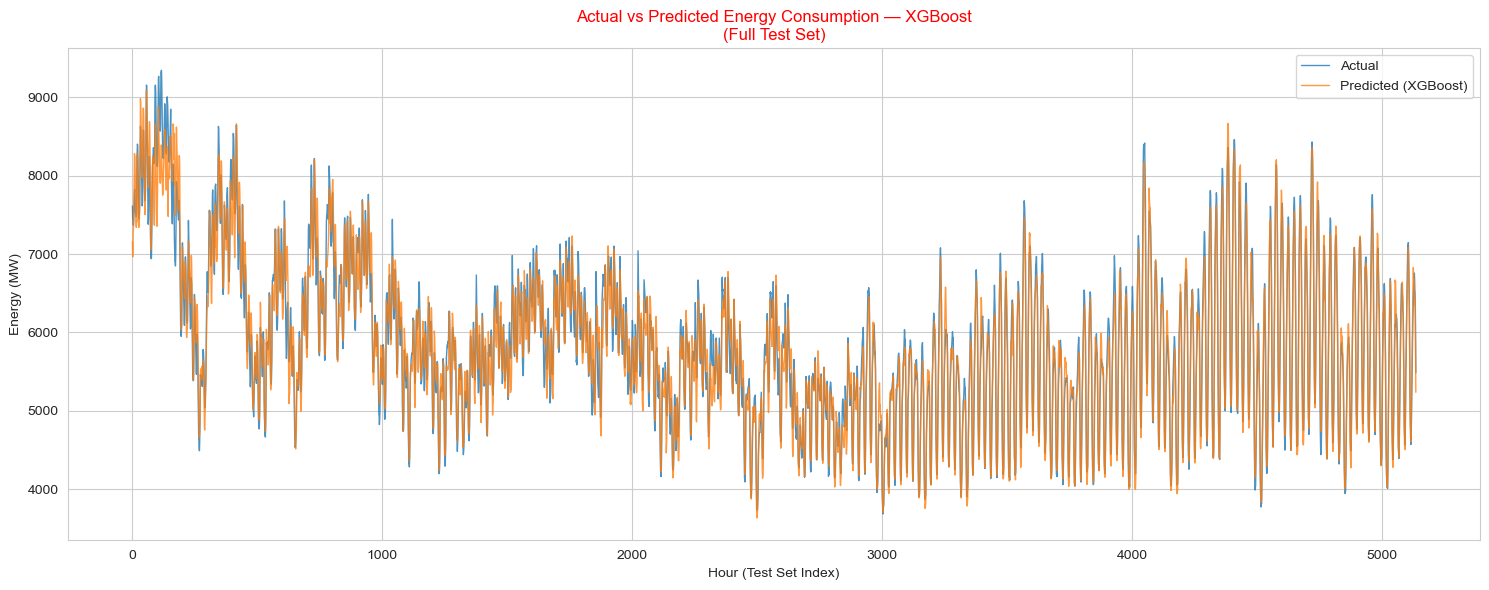

In [73]:
pred_col_map = {
    'XGBoost': 'XGB_Prediction',
    'Random Forest': 'RF_Prediction',
    'LightGBM': 'LGB_Prediction',
    'SARIMA': 'Sarima_Prediction'
}

best_col = pred_col_map[best_model_name]

plt.figure(figsize=(15, 6))
plt.plot(y_test.values, label='Actual', linewidth=1, alpha=0.8)
plt.plot(pred_res[best_col].values, label=f'Predicted ({best_model_name})', linewidth=1, alpha=0.8)
plt.title(f'Actual vs Predicted Energy Consumption — {best_model_name}\n(Full Test Set)', color='red')
plt.xlabel('Hour (Test Set Index)')
plt.ylabel('Energy (MW)')
plt.legend()
plt.tight_layout()
plt.show()

### 6. 30-Day Future Forecast


In [74]:
FEATURES = [
    'Hour',
    'DayOfWeek',
    'Month',
    'Year',
    'DayOfYear',
    'weekofyear',
    'Is_Holiday',
     'lag_24',
    'lag_168',
    'rolling_mean_24',
    'rolling_std_24'
]

TARGET = 'PJMW_MW'

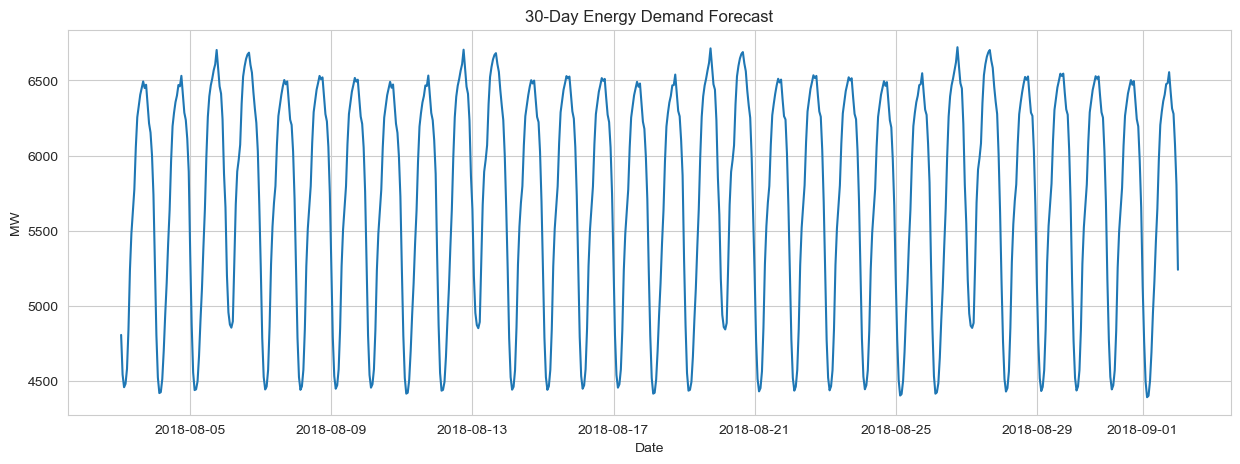

30-Day Forecast Completed Successfully


In [75]:
# Train model on complete data

X_all = data[FEATURES]
y_all = data[TARGET]

final_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6
)

final_model.fit(X_all, y_all)

# Create future timestamps (30 days × 24 hours)

future_dates = pd.date_range(
    start=data.index.max() + pd.Timedelta(hours=1),
    periods=720,
    freq='h'
)

future_df = pd.DataFrame(index=future_dates)

# Time Features

future_df['Hour'] = future_df.index.hour
future_df['DayOfWeek'] = future_df.index.dayofweek
future_df['Month'] = future_df.index.month
future_df['Year'] = future_df.index.year
future_df['DayOfYear'] = future_df.index.dayofyear
future_df['weekofyear'] = future_df.index.isocalendar().week.astype(int)

future_df['Is_Holiday'] = future_df.index.map(
    lambda x: 1 if x in us_holidays else 0
)

# Use latest available values for lag and rolling features

future_df['lag_24'] = data['lag_24'].iloc[-1]
future_df['lag_168'] = data['lag_168'].iloc[-1]
future_df['rolling_mean_24'] = data['rolling_mean_24'].iloc[-1]
future_df['rolling_std_24'] = data['rolling_std_24'].iloc[-1]

# Forecast

future_df['Forecast_MW'] = final_model.predict(
    future_df[FEATURES]
)

# Save

future_df[['Forecast_MW']].to_csv(
    '30_Day_Forecast.csv'
)

# Plot

plt.figure(figsize=(15,5))
plt.plot(
    future_df.index,
    future_df['Forecast_MW']
)
plt.title('30-Day Energy Demand Forecast')
plt.xlabel('Date')
plt.ylabel('MW')
plt.show()

print("30-Day Forecast Completed Successfully")

In [76]:
print(data.columns.tolist())

['PJMW_MW', 'Hour', 'DayOfWeek', 'Month', 'Year', 'DayOfYear', 'weekofyear', 'Is_Holiday', 'lag_24', 'lag_168', 'rolling_mean_24', 'rolling_std_24']


## Model Saving

In [77]:
import joblib
joblib.dump(xgb_model,'best_model1.pkl')  # or whichever model won

['best_model1.pkl']

In [78]:
import plotly
print(plotly.__version__)

6.3.0
